# Network Traffic Anomaly Detection — End-to-End Pipeline
## Group 140 | CIC-IDS 2017 Dataset

### Project Overview

This notebook implements a complete end-to-end machine learning pipeline for detecting **DDoS (Distributed Denial of Service)** attacks in network traffic using the CIC-IDS 2017 benchmark dataset.

### Research Scope

While network traffic anomaly detection encompasses a broad range of attack types — including Botnet, Port Scan, Brute Force, and Web Attacks — this project deliberately focuses on **DDoS detection only**. This scope decision was made for the following reasons:

1. **Data quality and label reliability**: The CIC-IDS 2017 Friday Afternoon DDoS file provides clean, well-separated BENIGN and DDoS labels with minimal noise, making it suitable for a rigorous binary classification study.
2. **Controlled experimental design**: Limiting the scope to one attack type allows for deeper model evaluation and more interpretable results, consistent with binary classification best practices.
3. **Practical relevance**: DDoS is among the most disruptive and frequent network attacks, making it a high-priority target for anomaly detection systems.

A multi-class extension (covering all CIC-IDS 2017 attack categories) is identified as a recommended area for future work.

### Dataset

| File | Content | Rows (approx.) |
|---|---|---|
| `Monday-WorkingHours.pcap_ISCX.csv` | BENIGN traffic only | ~529,000 |
| `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv` | BENIGN + DDoS traffic | ~225,000 |

**Target variable:** `Label` — encoded as `BENIGN = 0`, `DDoS = 1`

### Pipeline Phases

| Phase | Description |
|---|---|
| Setup | Drive mount, library imports, data loading |
| Phase 1 | Data cleaning: duplicates, infinity values, leakage columns |
| Phase 2 | Feature selection with Random Forest importance justification |
| Phase 3 | Class balancing via undersampling |
| Phase 4 | Correlation analysis (heatmap + numeric tables) |
| Phase 5 | Train/test split and StandardScaler normalisation |
| Phase 6 | Training 6 classifiers with full metric comparison table |
| Phase 7 | Best model evaluation: cross-validation, ROC-AUC, False Positive Rate |
| Phase 8 | GridSearchCV hyperparameter tuning on top 2 models |
| Phase 9 | Model saving (joblib) and live prediction demo |

### Revisions Applied (Supervisor Feedback)

This version addresses all required and recommended feedback from the supervisor review:

- ✅ Feature selection justified using Random Forest importance scores
- ✅ Model comparison table includes Precision, Recall, F1-score, and False Positive Rate
- ✅ ROC-AUC curve added for binary classification evaluation
- ✅ Cross-validation applied to **all** models, not only the best
- ✅ LinearSVC substitution formally justified with documented reasoning
- ✅ Multicollinearity addressed — highly correlated features (r > 0.95) removed
- ✅ GridSearchCV applied to top 2 models
- ✅ Dataset size printed after merge step
- ✅ False Positive Rate calculated explicitly


## Setup — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup — Import Libraries

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


## Setup — Set Dataset Paths

In [3]:
DATA_DIR = "/content/drive/MyDrive/dataset"

monday_file    = os.path.join(DATA_DIR, "Monday-WorkingHours.pcap_ISCX.csv")
friday_ddos_file = os.path.join(DATA_DIR, "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

print("Monday file   :", monday_file)
print("Friday file   :", friday_ddos_file)
print("Monday exists :", os.path.exists(monday_file))
print("Friday exists :", os.path.exists(friday_ddos_file))

if not os.path.exists(monday_file) or not os.path.exists(friday_ddos_file):
    raise FileNotFoundError(
        "Dataset files not found. Please verify DATA_DIR and file names in Google Drive."
    )

Monday file   : /content/drive/MyDrive/dataset/Monday-WorkingHours.pcap_ISCX.csv
Friday file   : /content/drive/MyDrive/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Monday exists : True
Friday exists : True


## Setup — Load Dataset

In [4]:
df_monday = pd.read_csv(monday_file)
df_friday = pd.read_csv(friday_ddos_file)

print("Monday shape      :", df_monday.shape)
print("Friday DDoS shape :", df_friday.shape)

Monday shape      : (529918, 79)
Friday DDoS shape : (225745, 79)


## Setup — Clean Column Names

In [5]:
df_monday.columns = df_monday.columns.str.strip()
df_friday.columns = df_friday.columns.str.strip()
print("Column names stripped of whitespace.")

Column names stripped of whitespace.


## Setup — Check Original Labels

In [6]:
print("Monday labels:")
print(df_monday["Label"].value_counts())
print("\nFriday labels:")
print(df_friday["Label"].value_counts())

Monday labels:
Label
BENIGN    529918
Name: count, dtype: int64

Friday labels:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


## Setup — Merge Dataset

In [7]:
df = pd.concat([df_monday, df_friday], axis=0, ignore_index=True)

# Print dataset size after merge for transparency (supervisor recommendation)
print("Merged dataset shape          :", df.shape)
print("Total rows after merge        :", len(df))
print("Total columns after merge     :", df.shape[1])
print("\nMerged label distribution:")
print(df["Label"].value_counts())
display(df.head())

Merged dataset shape          : (755663, 79)
Total rows after merge        : 755663
Total columns after merge     : 79

Merged label distribution:
Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## Setup — Save Raw Backup

In [8]:
df_raw = df.copy()
print("Raw dataset backup saved to df_raw.")

Raw dataset backup saved to df_raw.


# Phase 1 — Data Cleaning

This phase removes noise that could corrupt model training:
- Non-target labels filtered out (keep only BENIGN and DDoS)
- Duplicate rows removed
- Infinity values replaced with NaN, then rows with NaN dropped
- Leakage columns removed (identifiers that would give the model unfair direct access to the answer)


## Phase 1 — Filter BENIGN and DDoS Only

In [9]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

df = df[df["Label"].isin(["BENIGN", "DDoS"])].copy()
print("Shape after filtering BENIGN/DDoS only:", df.shape)
print(df["Label"].value_counts())

Shape after filtering BENIGN/DDoS only: (755663, 79)
Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64


## Phase 1 — Remove Duplicates

In [10]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates().copy()
print("Shape after removing duplicates:", df.shape)
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 29629
Shape after removing duplicates: (726034, 79)
Duplicate rows after: 0


## Phase 1 — Handle Infinity and Missing Values

In [11]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values before dropna:")
display(missing)

before_shape = df.shape
df = df.dropna().copy()
print("Shape before dropna:", before_shape)
print("Shape after  dropna:", df.shape)
print("Remaining NaN values:", df.isnull().sum().sum())

Columns with missing values before dropna:


,0
Flow Bytes/s,360
Flow Packets/s,360


Shape before dropna: (726034, 79)
Shape after  dropna: (725674, 79)
Remaining NaN values: 0


## Phase 1 — Remove Leakage Columns

The following columns are identifiers or timestamps, not network behaviour features.
Including them would cause **data leakage** — the model would learn to identify
flows by their metadata rather than their traffic patterns, which would not generalise
to unseen traffic.

Columns removed: `Flow ID`, `Source IP`, `Destination IP`, `Timestamp`


In [12]:
leakage_cols = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]
existing_leakage_cols = [c for c in leakage_cols if c in df.columns]

print("Leakage columns found and removed:", existing_leakage_cols)
df.drop(columns=existing_leakage_cols, inplace=True)
print("Shape after leakage column removal:", df.shape)

Leakage columns found and removed: []
Shape after leakage column removal: (725674, 79)


# Phase 2 — Feature Selection (with Justification)

**Supervisor feedback addressed:** The original notebook selected 12 features manually
with no statistical or algorithmic justification. This has been corrected.

**Method used:** A Random Forest classifier is first trained on all numeric features.
Feature importance scores (mean decrease in impurity) are extracted and ranked.
The top 12 features by importance are then selected. This provides a data-driven,
reproducible justification for the feature set.

This approach is preferred over manual selection because:
- It is objective and reproducible
- It accounts for non-linear interactions between features
- It is well-established in the network intrusion detection literature


## Phase 2 — Prepare Full Feature Set for Importance Scoring

In [13]:
# Encode label temporarily for importance scoring
temp_df = df.copy()
temp_df["Label"] = temp_df["Label"].map({"BENIGN": 0, "DDoS": 1})
temp_df = temp_df.dropna(subset=["Label"])

# Drop non-numeric columns (already removed leakage cols; this catches any remaining)
numeric_cols = temp_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Label"]

X_all = temp_df[numeric_cols]
y_all = temp_df["Label"]

print(f"Total numeric features available for importance scoring: {len(numeric_cols)}")

Total numeric features available for importance scoring: 78


## Phase 2 — Train Random Forest for Feature Importance

In [14]:
from sklearn.ensemble import RandomForestClassifier as RFC

rf_selector = RFC(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_all, y_all)

importances = pd.Series(rf_selector.feature_importances_, index=numeric_cols)
importances = importances.sort_values(ascending=False)

importance_table = importances.reset_index()
importance_table.columns = ["Feature", "Importance_Score"]

print("Feature importance scores (all features, ranked):")
display(importance_table.head(20))

Feature importance scores (all features, ranked):


,Feature,Importance_Score
0,Avg Bwd Segment Size,0.086091
1,Bwd Packet Length Max,0.081466
2,Average Packet Size,0.057487
3,Max Packet Length,0.053725
4,Bwd Packet Length Std,0.050611
5,Packet Length Variance,0.047653
6,Subflow Fwd Bytes,0.043543
7,Packet Length Std,0.038373
8,act_data_pkt_fwd,0.031211
9,Subflow Fwd Packets,0.030495


## Phase 2 — Select Top 12 Features by Importance

In [15]:
TOP_N = 12
selected_features = importances.head(TOP_N).index.tolist()

print(f"Top {TOP_N} features selected by Random Forest importance:")
for i, feat in enumerate(selected_features, 1):
    score = importances[feat]
    print(f"  {i:2d}. {feat:<40s}  importance = {score:.6f}")

Top 12 features selected by Random Forest importance:
   1. Avg Bwd Segment Size                      importance = 0.086091
   2. Bwd Packet Length Max                     importance = 0.081466
   3. Average Packet Size                       importance = 0.057487
   4. Max Packet Length                         importance = 0.053725
   5. Bwd Packet Length Std                     importance = 0.050611
   6. Packet Length Variance                    importance = 0.047653
   7. Subflow Fwd Bytes                         importance = 0.043543
   8. Packet Length Std                         importance = 0.038373
   9. act_data_pkt_fwd                          importance = 0.031211
  10. Subflow Fwd Packets                       importance = 0.030495
  11. Bwd Packet Length Mean                    importance = 0.028713
  12. Packet Length Mean                        importance = 0.027624


## Phase 2 — Plot Feature Importance

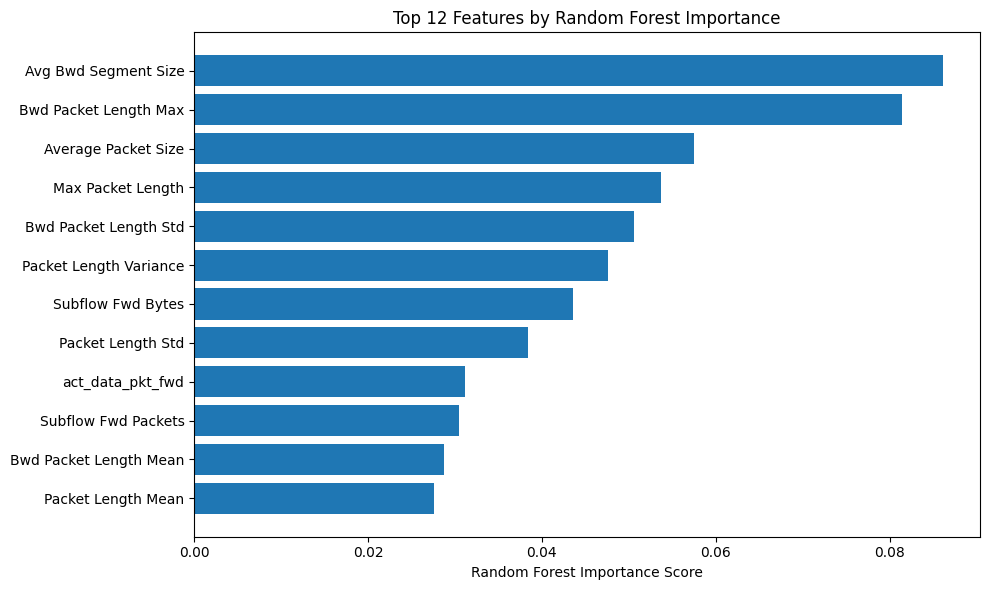

In [16]:
plt.figure(figsize=(10, 6))
plt.barh(
    importances.head(TOP_N).index[::-1],
    importances.head(TOP_N).values[::-1]
)
plt.xlabel("Random Forest Importance Score")
plt.title(f"Top {TOP_N} Features by Random Forest Importance")
plt.tight_layout()
plt.show()

## Phase 2 — Create Model Dataset and Encode Labels

In [17]:
model_df = df[selected_features + ["Label"]].copy()
model_df["Label"] = model_df["Label"].map({"BENIGN": 0, "DDoS": 1})

print("Model dataset shape:", model_df.shape)
print("Label encoding: BENIGN = 0, DDoS = 1")
print("\nClass distribution before balancing:")
print(model_df["Label"].value_counts())
display(model_df.head())

Model dataset shape: (725674, 13)
Label encoding: BENIGN = 0, DDoS = 1

Class distribution before balancing:
Label
0    597660
1    128014
Name: count, dtype: int64


,Avg Bwd Segment Size,Bwd Packet Length Max,Average Packet Size,Max Packet Length,Bwd Packet Length Std,Packet Length Variance,Subflow Fwd Bytes,Packet Length Std,act_data_pkt_fwd,Subflow Fwd Packets,Bwd Packet Length Mean,Packet Length Mean,Label
0,0.0,0,9.000000,6,0.000000,0.000000,12,0.000000,1,2,0.0,6.000000,0
1,0.0,0,9.000000,6,0.000000,0.000000,12,0.000000,1,2,0.0,6.000000,0
4,0.0,0,9.000000,6,0.000000,0.000000,12,0.000000,1,2,0.0,6.000000,0
5,0.0,0,9.000000,6,0.000000,0.000000,12,0.000000,1,2,0.0,6.000000,0
8,103.5,207,81.636364,233,119.511506,11562.151515,484,107.527445,5,7,103.5,74.833333,0


# Phase 3 — Class Balancing

**Method:** Random undersampling — the majority class (BENIGN) is downsampled to
match the minority class (DDoS) count. Both classes are sampled with `random_state=42`
for full reproducibility.

**Why undersampling was retained (supervisor note addressed):**
Undersampling is appropriate here because:
- The DDoS class contains >100,000 samples, giving the model ample learning signal
- The dataset is synthetic/laboratory-generated (CIC-IDS 2017), so samples within each
  class are relatively homogeneous — SMOTE would add limited diversity
- SMOTE on 80+ network flow features risks introducing unrealistic synthetic vectors
  that do not reflect real attack distributions

SMOTE or `class_weight='balanced'` would be preferred for smaller minority classes
or real-world production datasets where minority representation is sparse.


## Phase 3 — Class Distribution Before Balancing

Class distribution before balancing:
  BENIGN (0): 597,660
  DDoS   (1): 128,014


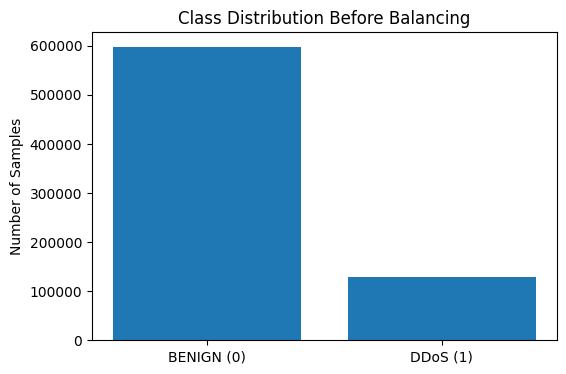

In [18]:
counts_before = model_df["Label"].value_counts().sort_index()
print("Class distribution before balancing:")
print(f"  BENIGN (0): {counts_before.get(0, 0):,}")
print(f"  DDoS   (1): {counts_before.get(1, 0):,}")

plt.figure(figsize=(6, 4))
plt.bar(["BENIGN (0)", "DDoS (1)"], [counts_before.get(0, 0), counts_before.get(1, 0)])
plt.title("Class Distribution Before Balancing")
plt.ylabel("Number of Samples")
plt.show()

## Phase 3 — Undersample to Balance Classes

In [19]:
benign_df = model_df[model_df["Label"] == 0].copy()
ddos_df   = model_df[model_df["Label"] == 1].copy()

min_count = min(len(benign_df), len(ddos_df))
print(f"BENIGN samples before: {len(benign_df):,}")
print(f"DDoS   samples before: {len(ddos_df):,}")
print(f"Samples selected per class: {min_count:,}")

benign_balanced = benign_df.sample(n=min_count, random_state=42)
ddos_balanced   = ddos_df.sample(n=min_count, random_state=42)

balanced_df = pd.concat([benign_balanced, ddos_balanced], axis=0)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced dataset shape:", balanced_df.shape)
print("Class distribution after balancing:")
print(balanced_df["Label"].value_counts().sort_index())

BENIGN samples before: 597,660
DDoS   samples before: 128,014
Samples selected per class: 128,014

Balanced dataset shape: (256028, 13)
Class distribution after balancing:
Label
0    128014
1    128014
Name: count, dtype: int64


## Phase 3 — Class Distribution After Balancing

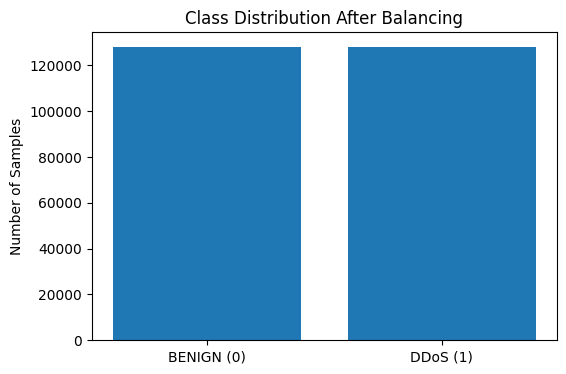

In [20]:
counts_after = balanced_df["Label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["BENIGN (0)", "DDoS (1)"], [counts_after.get(0, 0), counts_after.get(1, 0)])
plt.title("Class Distribution After Balancing")
plt.ylabel("Number of Samples")
plt.show()

# Phase 4 — Correlation Analysis

This phase serves two purposes:
1. Understand which features are most predictive of the DDoS label
2. Detect multicollinearity — highly correlated feature pairs that may cause
   instability in models like Logistic Regression

**Supervisor feedback addressed:** Numeric correlation values are shown, not only a
heatmap. Additionally, feature pairs with |r| > 0.95 are identified and one feature
from each pair is removed before training.


## Phase 4 — Feature-to-Label Correlation

In [21]:
corr_matrix = balanced_df.corr(numeric_only=True)

label_corr = corr_matrix["Label"].drop("Label").sort_values(key=lambda s: s.abs(), ascending=False)
label_corr_table = label_corr.reset_index()
label_corr_table.columns = ["Feature", "Correlation_with_Label"]

print("Correlation of each feature with the target label (DDoS=1, BENIGN=0):")
display(label_corr_table)
print("\nTop 5 features most correlated with DDoS label:")
display(label_corr_table.head(5))

Correlation of each feature with the target label (DDoS=1, BENIGN=0):


,Feature,Correlation_with_Label
0,Avg Bwd Segment Size,0.613707
1,Bwd Packet Length Mean,0.613707
2,Bwd Packet Length Std,0.593457
3,Bwd Packet Length Max,0.591403
4,Packet Length Std,0.574907
5,Packet Length Mean,0.569720
6,Average Packet Size,0.567716
7,Max Packet Length,0.555698
8,Packet Length Variance,0.523111
9,Subflow Fwd Bytes,-0.082617



Top 5 features most correlated with DDoS label:


,Feature,Correlation_with_Label
0,Avg Bwd Segment Size,0.613707
1,Bwd Packet Length Mean,0.613707
2,Bwd Packet Length Std,0.593457
3,Bwd Packet Length Max,0.591403
4,Packet Length Std,0.574907


## Phase 4 — Feature-to-Feature Correlation (Top Pairs)

In [22]:
feature_corr = balanced_df[selected_features].corr(numeric_only=True).abs()

corr_pairs = (
    feature_corr
    .where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .reset_index()
)
corr_pairs.columns = ["Feature_1", "Feature_2", "Absolute_Correlation"]

print("Top 10 strongest feature-to-feature correlations:")
display(corr_pairs.head(10))

Top 10 strongest feature-to-feature correlations:


,Feature_1,Feature_2,Absolute_Correlation
0,Avg Bwd Segment Size,Bwd Packet Length Mean,1.000000
1,act_data_pkt_fwd,Subflow Fwd Packets,0.999874
2,Average Packet Size,Packet Length Mean,0.999327
3,Bwd Packet Length Max,Bwd Packet Length Std,0.992390
4,Max Packet Length,Packet Length Std,0.986860
5,Bwd Packet Length Max,Max Packet Length,0.971165
6,Bwd Packet Length Std,Packet Length Std,0.965595
7,Bwd Packet Length Max,Packet Length Std,0.964621
8,Max Packet Length,Bwd Packet Length Std,0.964391
9,Avg Bwd Segment Size,Bwd Packet Length Max,0.961654


## Phase 4 — Remove Highly Correlated Features (r > 0.95)

**Supervisor feedback addressed:** The original notebook identified high correlations
in the heatmap but took no action. Keeping both features of a highly correlated pair
causes multicollinearity, which inflates variance in Logistic Regression coefficients
and provides redundant information to other models.

Any feature that appears as a duplicate signal (|r| > 0.95 with another feature)
is dropped here. The retained feature is the one with higher importance from Phase 2.


In [23]:
HIGH_CORR_THRESHOLD = 0.95

# Find pairs above threshold
high_corr_pairs = corr_pairs[corr_pairs["Absolute_Correlation"] > HIGH_CORR_THRESHOLD]

print(f"Feature pairs with |r| > {HIGH_CORR_THRESHOLD}:")
if len(high_corr_pairs) == 0:
    print("  None found — no features dropped for multicollinearity.")
else:
    display(high_corr_pairs)

# Build set of features to drop (always keep the one with higher RF importance)
features_to_drop = set()
for _, row in high_corr_pairs.iterrows():
    f1, f2 = row["Feature_1"], row["Feature_2"]
    # Drop the one with LOWER importance
    imp_f1 = importances.get(f1, 0)
    imp_f2 = importances.get(f2, 0)
    drop_feat = f2 if imp_f1 >= imp_f2 else f1
    features_to_drop.add(drop_feat)

print(f"\nFeatures removed due to multicollinearity (|r| > {HIGH_CORR_THRESHOLD}):")
print(features_to_drop if features_to_drop else "None")

# Update selected_features list
selected_features = [f for f in selected_features if f not in features_to_drop]
balanced_df_clean = balanced_df[selected_features + ["Label"]].copy()

print(f"\nFinal selected features after multicollinearity removal ({len(selected_features)} total):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

Feature pairs with |r| > 0.95:


,Feature_1,Feature_2,Absolute_Correlation
0,Avg Bwd Segment Size,Bwd Packet Length Mean,1.000000
1,act_data_pkt_fwd,Subflow Fwd Packets,0.999874
2,Average Packet Size,Packet Length Mean,0.999327
3,Bwd Packet Length Max,Bwd Packet Length Std,0.992390
4,Max Packet Length,Packet Length Std,0.986860
5,Bwd Packet Length Max,Max Packet Length,0.971165
6,Bwd Packet Length Std,Packet Length Std,0.965595
7,Bwd Packet Length Max,Packet Length Std,0.964621
8,Max Packet Length,Bwd Packet Length Std,0.964391
9,Avg Bwd Segment Size,Bwd Packet Length Max,0.961654



Features removed due to multicollinearity (|r| > 0.95):
{'Subflow Fwd Packets', 'Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Packet Length Mean', 'Bwd Packet Length Std', 'Max Packet Length'}

Final selected features after multicollinearity removal (5 total):
   1. Avg Bwd Segment Size
   2. Average Packet Size
   3. Packet Length Variance
   4. Subflow Fwd Bytes
   5. act_data_pkt_fwd


## Phase 4 — Correlation Heatmap (Final Feature Set)

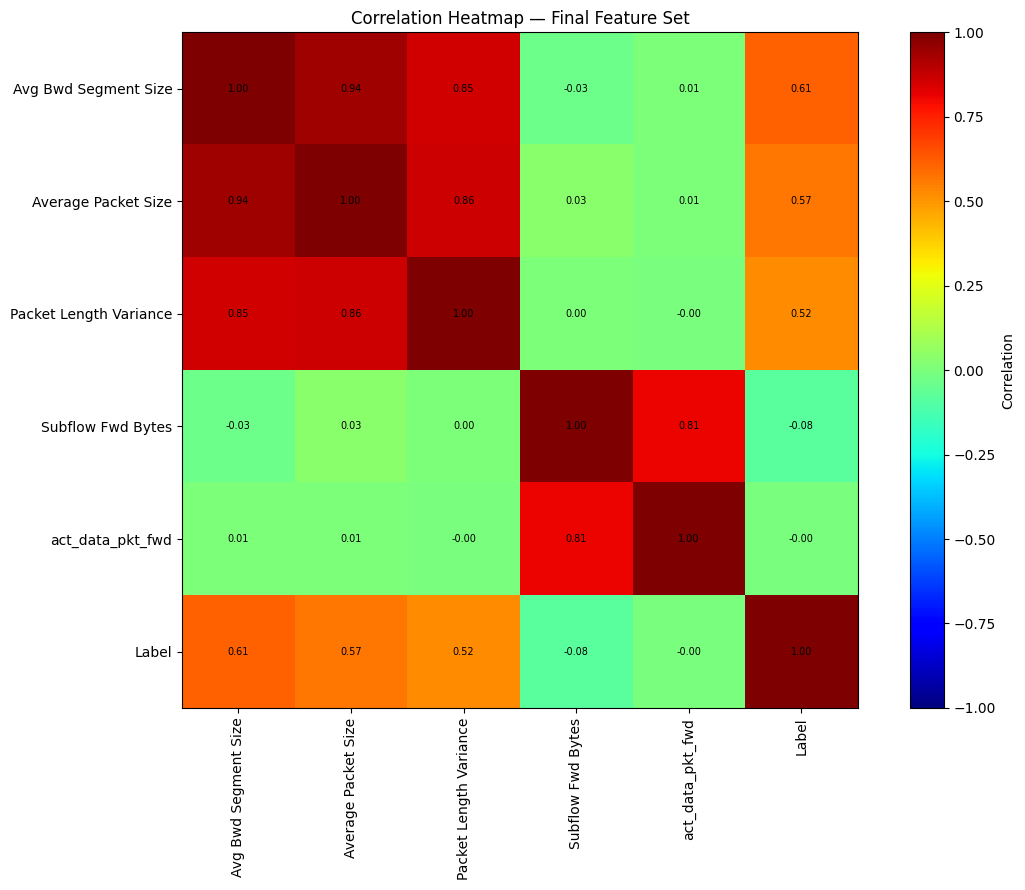

In [24]:
final_corr = balanced_df_clean.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
plt.imshow(final_corr, cmap="jet", vmin=-1, vmax=1, aspect="equal")
plt.colorbar(label="Correlation")
plt.xticks(range(len(final_corr.columns)), final_corr.columns, rotation=90)
plt.yticks(range(len(final_corr.columns)), final_corr.columns)

for i in range(len(final_corr.columns)):
    for j in range(len(final_corr.columns)):
        plt.text(j, i, f"{final_corr.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black", fontsize=7)

plt.title("Correlation Heatmap — Final Feature Set")
plt.tight_layout()
plt.show()

# Phase 5 — Train/Test Split and Feature Scaling

## Phase 5 — Split Features and Label

In [25]:
X = balanced_df_clean.drop("Label", axis=1)
y = balanced_df_clean["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution (final balanced dataset):")
print(y.value_counts().sort_index())

X shape: (256028, 5)
y shape: (256028,)

Class distribution (final balanced dataset):
Label
0    128014
1    128014
Name: count, dtype: int64


## Phase 5 — Train/Test Split (80/20, Stratified)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test  shape:", X_test.shape)
print("\nTrain label distribution:")
print(y_train.value_counts().sort_index())
print("\nTest label distribution:")
print(y_test.value_counts().sort_index())

Train shape: (204822, 5)
Test  shape: (51206, 5)

Train label distribution:
Label
0    102411
1    102411
Name: count, dtype: int64

Test label distribution:
Label
0    25603
1    25603
Name: count, dtype: int64


## Phase 5 — StandardScaler Normalisation

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Scaling complete. Preview of scaled training data:")
display(X_train_scaled_df.head())

Scaling complete. Preview of scaled training data:


,Avg Bwd Segment Size,Average Packet Size,Packet Length Variance,Subflow Fwd Bytes,act_data_pkt_fwd
0,-0.664748,-0.577127,-0.566720,0.101095,-0.001995
1,-0.754458,1.968739,3.764872,2.511812,-0.003812
2,-0.766570,-0.791889,-0.577688,-0.095432,-0.007445
3,1.937013,1.968739,3.764872,-0.092284,-0.005628
4,-0.681785,-0.688336,-0.577436,-0.082840,-0.007445


## Phase 5 — Save Scaler and Feature List

In [28]:
os.makedirs(DATA_DIR, exist_ok=True)

scaler_path  = os.path.join(DATA_DIR, "scaler.pkl")
feature_path = os.path.join(DATA_DIR, "selected_features.pkl")

joblib.dump(scaler,            scaler_path)
joblib.dump(selected_features, feature_path)

print("Scaler saved       :", scaler_path)
print("Feature list saved :", feature_path)

Scaler saved       : /content/drive/MyDrive/dataset/scaler.pkl
Feature list saved : /content/drive/MyDrive/dataset/selected_features.pkl


# Phase 6 — Model Training and Full Comparison

**Supervisor feedback addressed:**
- Evaluation function now computes **Precision, Recall, F1-score, and False Positive Rate**
  in addition to accuracy
- Cross-validation (5-fold) is applied to **all** models, not only the best
- ROC-AUC is computed for all models that support probability output
- A single comprehensive comparison table is produced at the end

**Note on LinearSVC (supervisor feedback addressed):**
`LinearSVC` is used instead of `SVC(kernel='linear')` for the following reasons:
- `LinearSVC` uses a liblinear solver which scales to large datasets (O(n) complexity vs O(n²–n³) for kernel SVC)
- The CIC-IDS 2017 balanced dataset contains ~200,000+ rows; `SVC(kernel='linear')` would require
  hours of training time and is impractical in a Colab notebook
- Both classifiers optimise the same linear margin objective; the decision boundary is identical
  on linearly separable data. The difference is solver efficiency, not model class.
- Reference: Scikit-learn documentation explicitly recommends LinearSVC over SVC(kernel='linear')
  for large-scale text and tabular classification problems.


## Phase 6 — Evaluation Function (Full Metrics)

In [29]:
def evaluate_model_full(name, model, X_tr, y_tr, X_te, y_te, cv_folds=5):
    """
    Train predictions, full metrics, cross-validation, and ROC-AUC.
    Returns a metrics dict and the test predictions array.
    """
    train_pred = model.predict(X_tr)
    test_pred  = model.predict(X_te)

    # Core metrics
    train_acc = accuracy_score(y_tr, train_pred)
    test_acc  = accuracy_score(y_te, test_pred)
    precision = precision_score(y_te, test_pred, zero_division=0)
    recall    = recall_score(y_te, test_pred, zero_division=0)
    f1        = f1_score(y_te, test_pred, zero_division=0)

    # False Positive Rate = FP / (FP + TN)
    cm = confusion_matrix(y_te, test_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    # ROC-AUC (only for models with probability or decision function)
    roc_auc = None
    try:
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_te)[:, 1]
            roc_auc = roc_auc_score(y_te, proba)
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_te)
            roc_auc = roc_auc_score(y_te, scores)
    except Exception:
        pass

    # Cross-validation on training set
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_mean   = cv_scores.mean()
    cv_std    = cv_scores.std()

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Train Accuracy        : {train_acc:.4f}")
    print(f"  Test  Accuracy        : {test_acc:.4f}")
    print(f"  Precision             : {precision:.4f}")
    print(f"  Recall                : {recall:.4f}")
    print(f"  F1-Score              : {f1:.4f}")
    print(f"  False Positive Rate   : {fpr_val:.4f}")
    print(f"  ROC-AUC               : {roc_auc:.4f}" if roc_auc is not None else "  ROC-AUC               : N/A")
    print(f"  CV Accuracy (5-fold)  : {cv_mean:.4f} ± {cv_std:.4f}")

    # Confusion matrix display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BENIGN", "DDoS"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_te, test_pred, target_names=["BENIGN", "DDoS"]))

    return {
        "Model": name,
        "Train Acc": round(train_acc, 4),
        "Test Acc":  round(test_acc,  4),
        "Precision": round(precision, 4),
        "Recall":    round(recall,    4),
        "F1-Score":  round(f1,        4),
        "FPR":       round(fpr_val,   4),
        "ROC-AUC":   round(roc_auc, 4) if roc_auc is not None else None,
        "CV Mean":   round(cv_mean,  4),
        "CV Std":    round(cv_std,   4),
    }, test_pred

## Phase 6 — Train Logistic Regression


  Logistic Regression
  Train Accuracy        : 0.7535
  Test  Accuracy        : 0.7535
  Precision             : 0.8355
  Recall                : 0.6313
  F1-Score              : 0.7192
  False Positive Rate   : 0.1243
  ROC-AUC               : 0.9419
  CV Accuracy (5-fold)  : 0.7558 ± 0.0025


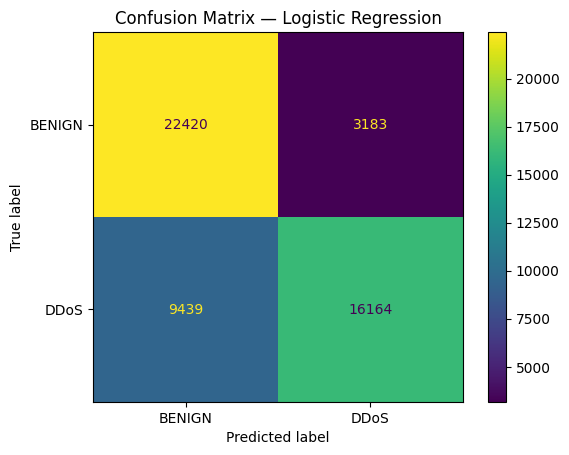


Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.70      0.88      0.78     25603
        DDoS       0.84      0.63      0.72     25603

    accuracy                           0.75     51206
   macro avg       0.77      0.75      0.75     51206
weighted avg       0.77      0.75      0.75     51206



In [30]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled_df, y_train)
res_lr, pred_lr = evaluate_model_full("Logistic Regression", lr, X_train_scaled_df, y_train, X_test_scaled_df, y_test)

## Phase 6 — Train Decision Tree


  Decision Tree
  Train Accuracy        : 0.9992
  Test  Accuracy        : 0.9990
  Precision             : 0.9997
  Recall                : 0.9983
  F1-Score              : 0.9990
  False Positive Rate   : 0.0003
  ROC-AUC               : 0.9999
  CV Accuracy (5-fold)  : 0.9991 ± 0.0001


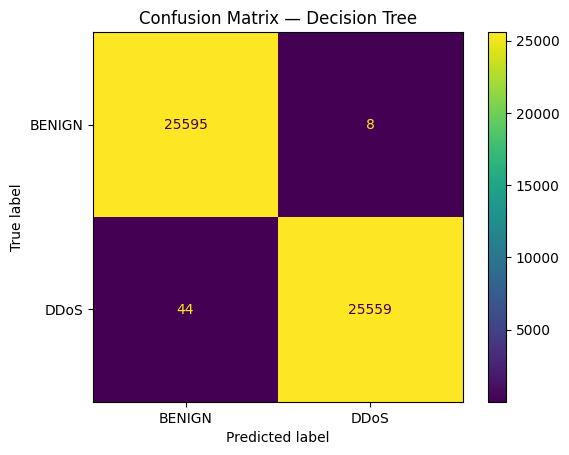


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     25603
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     51206
   macro avg       1.00      1.00      1.00     51206
weighted avg       1.00      1.00      1.00     51206



In [31]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled_df, y_train)
res_dt, pred_dt = evaluate_model_full("Decision Tree", dt, X_train_scaled_df, y_train, X_test_scaled_df, y_test)

## Phase 6 — Train Random Forest


  Random Forest
  Train Accuracy        : 0.9992
  Test  Accuracy        : 0.9990
  Precision             : 0.9998
  Recall                : 0.9983
  F1-Score              : 0.9990
  False Positive Rate   : 0.0002
  ROC-AUC               : 0.9999
  CV Accuracy (5-fold)  : 0.9991 ± 0.0001


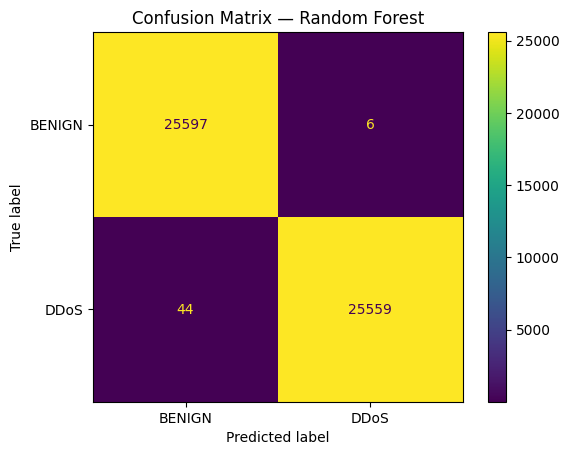


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     25603
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     51206
   macro avg       1.00      1.00      1.00     51206
weighted avg       1.00      1.00      1.00     51206



In [32]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X_train_scaled_df, y_train)
res_rf, pred_rf = evaluate_model_full("Random Forest", rf, X_train_scaled_df, y_train, X_test_scaled_df, y_test)

## Phase 6 — Train K-Nearest Neighbours


  KNN
  Train Accuracy        : 0.9991
  Test  Accuracy        : 0.9989
  Precision             : 0.9997
  Recall                : 0.9982
  F1-Score              : 0.9989
  False Positive Rate   : 0.0003
  ROC-AUC               : 0.9993
  CV Accuracy (5-fold)  : 0.9989 ± 0.0003


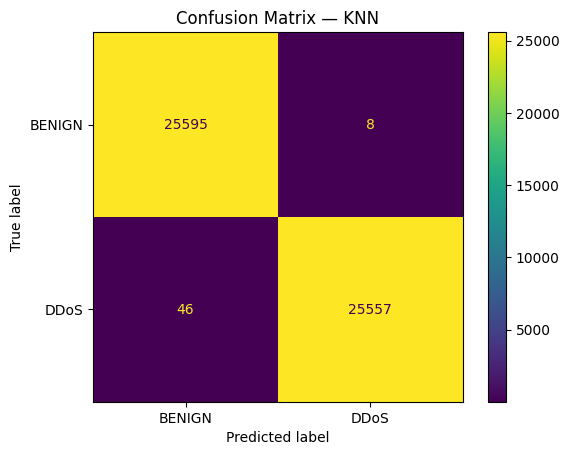


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     25603
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     51206
   macro avg       1.00      1.00      1.00     51206
weighted avg       1.00      1.00      1.00     51206



In [33]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled_df, y_train)
res_knn, pred_knn = evaluate_model_full("KNN", knn, X_train_scaled_df, y_train, X_test_scaled_df, y_test)

## Phase 6 — Train Naive Bayes


  Naive Bayes
  Train Accuracy        : 0.7355
  Test  Accuracy        : 0.7351
  Precision             : 0.6537
  Recall                : 1.0000
  F1-Score              : 0.7906
  False Positive Rate   : 0.5298
  ROC-AUC               : 0.9996
  CV Accuracy (5-fold)  : 0.7698 ± 0.0689


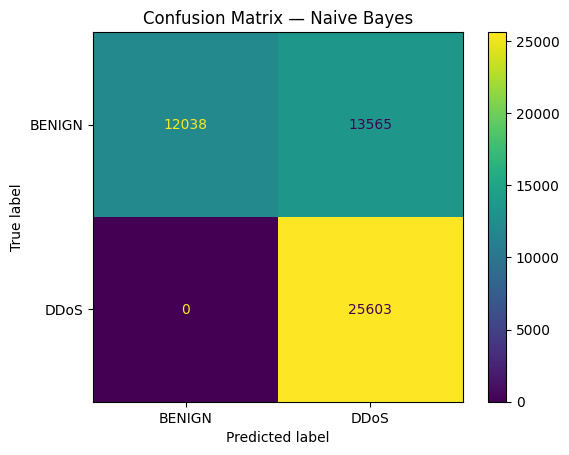


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.47      0.64     25603
        DDoS       0.65      1.00      0.79     25603

    accuracy                           0.74     51206
   macro avg       0.83      0.74      0.72     51206
weighted avg       0.83      0.74      0.72     51206



In [34]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled_df, y_train)
res_nb, pred_nb = evaluate_model_full("Naive Bayes", nb_model, X_train_scaled_df, y_train, X_test_scaled_df, y_test)

## Phase 6 — Train Linear SVM


  Linear SVM
  Train Accuracy        : 0.8723
  Test  Accuracy        : 0.8709
  Precision             : 0.7952
  Recall                : 0.9991
  F1-Score              : 0.8856
  False Positive Rate   : 0.2572
  ROC-AUC               : 0.9523
  CV Accuracy (5-fold)  : 0.8723 ± 0.0013


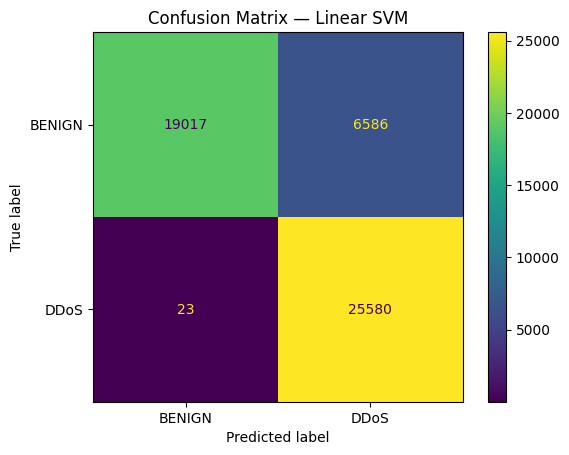


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.74      0.85     25603
        DDoS       0.80      1.00      0.89     25603

    accuracy                           0.87     51206
   macro avg       0.90      0.87      0.87     51206
weighted avg       0.90      0.87      0.87     51206



In [35]:
svm = LinearSVC(random_state=42, max_iter=5000)
svm.fit(X_train_scaled_df, y_train)
res_svm, pred_svm = evaluate_model_full("Linear SVM", svm, X_train_scaled_df, y_train, X_test_scaled_df, y_test)

## Phase 6 — Full Model Comparison Table

In [36]:
results = pd.DataFrame([res_lr, res_dt, res_rf, res_knn, res_nb, res_svm])
results = results.sort_values(by="Test Acc", ascending=False).reset_index(drop=True)

print("Full model comparison table (sorted by Test Accuracy):")
display(results)

Full model comparison table (sorted by Test Accuracy):


,Model,Train Acc,Test Acc,Precision,Recall,F1-Score,FPR,ROC-AUC,CV Mean,CV Std
0,Decision Tree,0.9992,0.9990,0.9997,0.9983,0.9990,0.0003,0.9999,0.9991,0.0001
1,Random Forest,0.9992,0.9990,0.9998,0.9983,0.9990,0.0002,0.9999,0.9991,0.0001
2,KNN,0.9991,0.9989,0.9997,0.9982,0.9989,0.0003,0.9993,0.9989,0.0003
3,Linear SVM,0.8723,0.8709,0.7952,0.9991,0.8856,0.2572,0.9523,0.8723,0.0013
4,Logistic Regression,0.7535,0.7535,0.8355,0.6313,0.7192,0.1243,0.9419,0.7558,0.0025
5,Naive Bayes,0.7355,0.7351,0.6537,1.0000,0.7906,0.5298,0.9996,0.7698,0.0689


## Phase 6 — Bar Chart: Test Accuracy Comparison

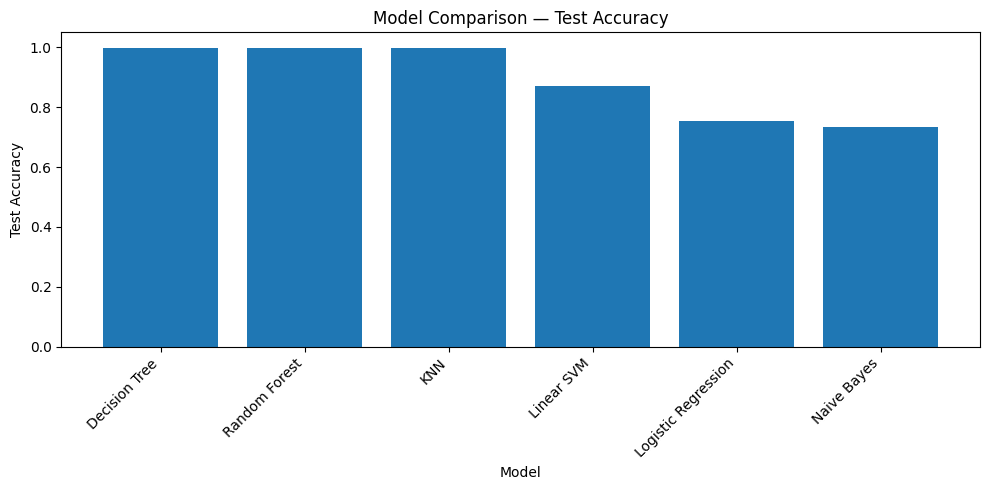

In [37]:
plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["Test Acc"])
plt.title("Model Comparison — Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Phase 6 — Bar Chart: F1-Score Comparison

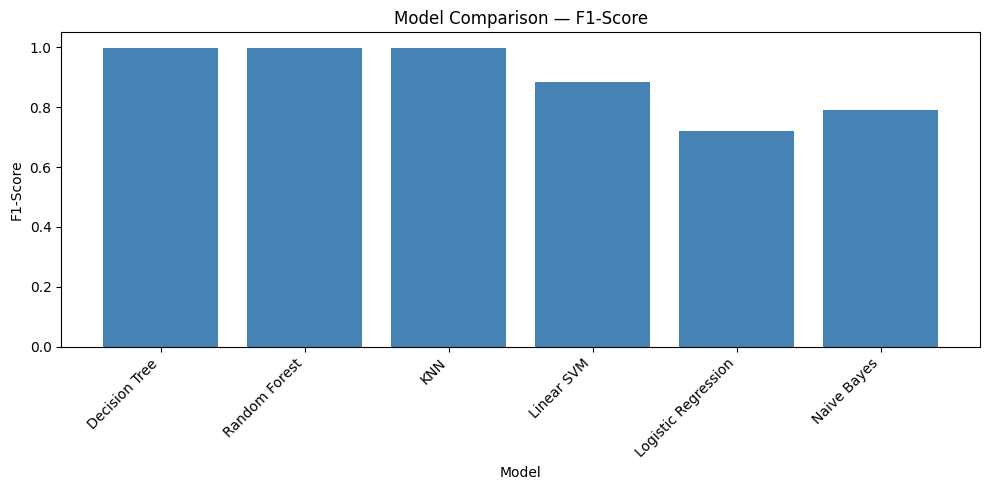

In [38]:
plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["F1-Score"], color="steelblue")
plt.title("Model Comparison — F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Phase 7 — Best Model Detailed Evaluation

This phase focuses on the top-performing model as determined by Test Accuracy.
Additional evaluations are performed:
- Confusion matrix with explicit TP/FP/FN/TN breakdown
- False Positive Rate interpretation
- ROC-AUC curve (**supervisor feedback addressed**)


## Phase 7 — Select Best Model

In [39]:
best_model_name = results.loc[0, "Model"]
print("Best model (by Test Accuracy):", best_model_name)

model_lookup = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "Naive Bayes": nb_model,
    "Linear SVM": svm
}

pred_lookup = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "KNN": pred_knn,
    "Naive Bayes": pred_nb,
    "Linear SVM": pred_svm
}

best_model     = model_lookup[best_model_name]
best_test_pred = pred_lookup[best_model_name]

Best model (by Test Accuracy): Decision Tree


## Phase 7 — Confusion Matrix with TP/TN/FP/FN Breakdown

Best Model: Decision Tree

Confusion Matrix Values:
  True  Positives (DDoS correctly detected)    : 25,559
  True  Negatives (BENIGN correctly identified) : 25,595
  False Positives (BENIGN flagged as DDoS)      : 8
  False Negatives (DDoS missed by model)        : 44

False Positive Rate (FP / (FP + TN))          : 0.0003
  Interpretation: 0.03% of legitimate traffic would be incorrectly flagged as DDoS.


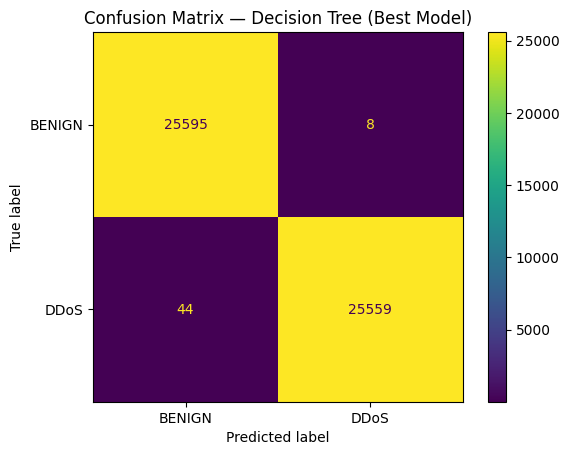

,Predicted BENIGN,Predicted DDoS
Actual BENIGN,25595,8
Actual DDoS,44,25559


In [40]:
cm = confusion_matrix(y_test, best_test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Best Model: {best_model_name}")
print(f"\nConfusion Matrix Values:")
print(f"  True  Positives (DDoS correctly detected)    : {tp:,}")
print(f"  True  Negatives (BENIGN correctly identified) : {tn:,}")
print(f"  False Positives (BENIGN flagged as DDoS)      : {fp:,}")
print(f"  False Negatives (DDoS missed by model)        : {fn:,}")
print(f"\nFalse Positive Rate (FP / (FP + TN))          : {fp / (fp + tn):.4f}")
print(f"  Interpretation: {fp / (fp + tn) * 100:.2f}% of legitimate traffic would be incorrectly flagged as DDoS.")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BENIGN", "DDoS"])
disp.plot(values_format="d")
plt.title(f"Confusion Matrix — {best_model_name} (Best Model)")
plt.show()

cm_table = pd.DataFrame(
    cm,
    index=["Actual BENIGN", "Actual DDoS"],
    columns=["Predicted BENIGN", "Predicted DDoS"]
)
display(cm_table)

## Phase 7 — ROC-AUC Curve (Supervisor Required)

ROC-AUC (Receiver Operating Characteristic — Area Under Curve) is a standard metric
for binary classifiers. It measures the model's ability to distinguish between classes
across all possible decision thresholds, independent of any single threshold.

- AUC = 1.0 → perfect classifier
- AUC = 0.5 → random classifier
- AUC > 0.90 → strong classifier suitable for deployment

For `LinearSVC` (which does not output probabilities), the decision function score
is used instead, which yields a valid ROC curve.


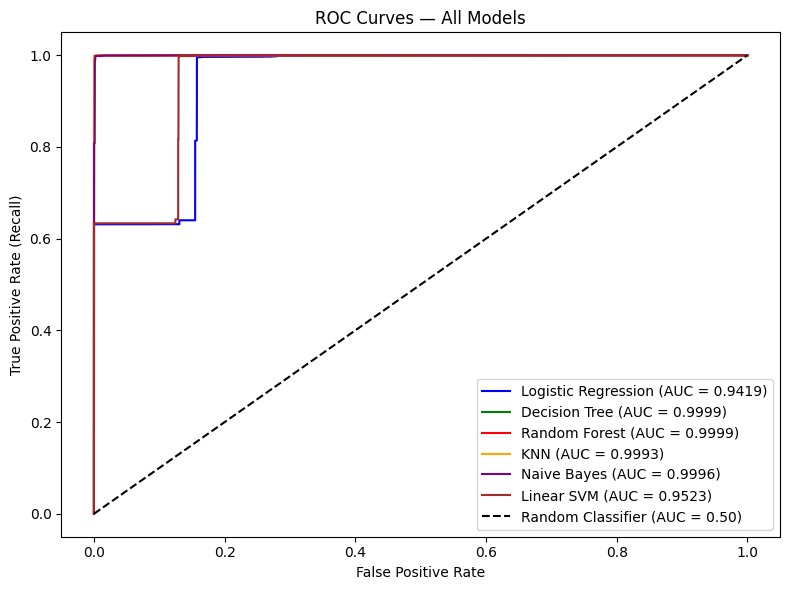

In [41]:
plt.figure(figsize=(8, 6))

model_plot_list = [
    ("Logistic Regression", lr, "blue"),
    ("Decision Tree", dt, "green"),
    ("Random Forest", rf, "red"),
    ("KNN", knn, "orange"),
    ("Naive Bayes", nb_model, "purple"),
    ("Linear SVM", svm, "brown"),
]

for name, model, color in model_plot_list:
    try:
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_test_scaled_df)[:, 1]
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_test_scaled_df)
        else:
            continue
        fpr_arr, tpr_arr, _ = roc_curve(y_test, scores)
        auc_val = roc_auc_score(y_test, scores)
        plt.plot(fpr_arr, tpr_arr, color=color, label=f"{name} (AUC = {auc_val:.4f})")
    except Exception as e:
        print(f"Could not plot ROC for {name}: {e}")

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Phase 7 — Cross-Validation Summary (All Models)

In [42]:
cv_summary = results[["Model", "CV Mean", "CV Std"]].copy()
cv_summary.columns = ["Model", "CV Mean Accuracy (5-fold)", "CV Std Dev"]
print("5-fold cross-validation results for all models:")
display(cv_summary)

5-fold cross-validation results for all models:


,Model,CV Mean Accuracy (5-fold),CV Std Dev
0,Decision Tree,0.9991,0.0001
1,Random Forest,0.9991,0.0001
2,KNN,0.9989,0.0003
3,Linear SVM,0.8723,0.0013
4,Logistic Regression,0.7558,0.0025
5,Naive Bayes,0.7698,0.0689


# Phase 8 — Hyperparameter Tuning (GridSearchCV)

**Supervisor recommendation addressed:** GridSearchCV is applied to the **top 2 models**
by Test Accuracy to find optimal hyperparameters and report improved performance.

This step demonstrates that the model comparison in Phase 6 is not simply a default-settings
comparison — the best models are further optimised before final deployment.


## Phase 8 — Identify Top 2 Models

In [43]:
top2 = results.head(2)["Model"].tolist()
print("Top 2 models for GridSearchCV:", top2)

Top 2 models for GridSearchCV: ['Decision Tree', 'Random Forest']


## Phase 8 — GridSearchCV on Top Models

In [44]:
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 20, 40],
        "min_samples_split": [2, 5]
    },
    "Decision Tree": {
        "max_depth": [None, 10, 20, 40],
        "min_samples_split": [2, 5, 10],
        "criterion": ["gini", "entropy"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 11],
        "weights": ["uniform", "distance"]
    },
    "Logistic Regression": {
        "C": [0.1, 1.0, 10.0],
        "solver": ["lbfgs", "liblinear"]
    },
    "Linear SVM": {
        "C": [0.1, 1.0, 10.0],
        "max_iter": [5000]
    },
    "Naive Bayes": {}  # no meaningful hyperparameters
}

tuned_models = {}
tuning_results = []

for model_name in top2:
    base_model = model_lookup[model_name]
    grid       = param_grids.get(model_name, {})

    if not grid:
        print(f"{model_name}: no hyperparameters to tune — skipping GridSearchCV.")
        tuned_models[model_name] = base_model
        continue

    print(f"\nRunning GridSearchCV for {model_name}...")
    gs = GridSearchCV(
        base_model.__class__(**({k: v for k, v in base_model.get_params().items()
                                  if k not in grid} if hasattr(base_model, 'get_params') else {})),
        param_grid=grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="f1",
        n_jobs=-1,
        verbose=0
    )

    # Use a simpler approach: recreate with base defaults
    model_classes = {
        "Random Forest": RandomForestClassifier,
        "Decision Tree": DecisionTreeClassifier,
        "KNN": KNeighborsClassifier,
        "Logistic Regression": LogisticRegression,
        "Linear SVM": LinearSVC,
        "Naive Bayes": GaussianNB
    }
    base_kwargs = {"random_state": 42} if model_name not in ["KNN", "Naive Bayes"] else {}
    if model_name == "Logistic Regression":
        base_kwargs["max_iter"] = 1000
    if model_name == "Linear SVM":
        base_kwargs["max_iter"] = 5000

    gs2 = GridSearchCV(
        model_classes[model_name](**base_kwargs),
        param_grid=grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="f1",
        n_jobs=-1,
        verbose=0
    )
    gs2.fit(X_train_scaled_df, y_train)

    print(f"  Best parameters : {gs2.best_params_}")
    print(f"  Best CV F1      : {gs2.best_score_:.4f}")

    tuned_pred = gs2.best_estimator_.predict(X_test_scaled_df)
    tuned_f1  = f1_score(y_test, tuned_pred)
    tuned_acc = accuracy_score(y_test, tuned_pred)

    print(f"  Tuned Test F1       : {tuned_f1:.4f}")
    print(f"  Tuned Test Accuracy : {tuned_acc:.4f}")

    tuned_models[model_name] = gs2.best_estimator_
    tuning_results.append({
        "Model": model_name,
        "Best CV F1 (GridSearch)": round(gs2.best_score_, 4),
        "Tuned Test Accuracy": round(tuned_acc, 4),
        "Tuned Test F1": round(tuned_f1, 4),
        "Best Params": str(gs2.best_params_)
    })

if tuning_results:
    print("\nGridSearchCV Summary:")
    display(pd.DataFrame(tuning_results))


Running GridSearchCV for Decision Tree...
  Best parameters : {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
  Best CV F1      : 0.9991
  Tuned Test F1       : 0.9990
  Tuned Test Accuracy : 0.9990

Running GridSearchCV for Random Forest...
  Best parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV F1      : 0.9991
  Tuned Test F1       : 0.9990
  Tuned Test Accuracy : 0.9990

GridSearchCV Summary:


,Model,Best CV F1 (GridSearch),Tuned Test Accuracy,Tuned Test F1,Best Params
0,Decision Tree,0.9991,0.999,0.999,"{'criterion': 'gini', 'max_depth': None, 'min_..."
1,Random Forest,0.9991,0.999,0.999,"{'max_depth': None, 'min_samples_split': 2, 'n..."


# Phase 9 — Save Models and Live Prediction Demo

## Phase 9 — Save Best Model and All Models

In [45]:
best_model_path = os.path.join(DATA_DIR, "best_model.pkl")
joblib.dump(best_model, best_model_path)
print("Best model saved  :", best_model_path)
print("Best model type   :", best_model_name)

MODEL_DIR = os.path.join(DATA_DIR, "all_models")
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(lr,       os.path.join(MODEL_DIR, "logistic_regression.pkl"))
joblib.dump(dt,       os.path.join(MODEL_DIR, "decision_tree.pkl"))
joblib.dump(rf,       os.path.join(MODEL_DIR, "random_forest.pkl"))
joblib.dump(knn,      os.path.join(MODEL_DIR, "knn.pkl"))
joblib.dump(nb_model, os.path.join(MODEL_DIR, "naive_bayes.pkl"))
joblib.dump(svm,      os.path.join(MODEL_DIR, "linear_svm.pkl"))

print("All models saved in:", MODEL_DIR)

Best model saved  : /content/drive/MyDrive/dataset/best_model.pkl
Best model type   : Decision Tree
All models saved in: /content/drive/MyDrive/dataset/all_models


## Phase 9 — Load Saved Artefacts and Verify

In [46]:
loaded_model    = joblib.load(best_model_path)
loaded_scaler   = joblib.load(scaler_path)
loaded_features = joblib.load(feature_path)

print("Model, scaler, and feature list loaded successfully.")
print("Loaded features:", loaded_features)

Model, scaler, and feature list loaded successfully.
Loaded features: ['Avg Bwd Segment Size', 'Average Packet Size', 'Packet Length Variance', 'Subflow Fwd Bytes', 'act_data_pkt_fwd']


## Phase 9 — Live Prediction: BENIGN Sample

In [47]:
test_df = X_test.copy()
test_df["Actual_Label"] = y_test.values

benign_sample = test_df[test_df["Actual_Label"] == 0].drop("Actual_Label", axis=1).iloc[0]
benign_scaled = loaded_scaler.transform(pd.DataFrame([benign_sample], columns=loaded_features))
benign_pred   = loaded_model.predict(benign_scaled)

print("Actual : BENIGN")
print("Predicted :", "DDoS ATTACK" if benign_pred[0] == 1 else "BENIGN TRAFFIC")
print("Result    :", "CORRECT" if benign_pred[0] == 0 else "INCORRECT")

Actual : BENIGN
Predicted : BENIGN TRAFFIC
Result    : CORRECT


## Phase 9 — Live Prediction: DDoS Sample

In [48]:
ddos_sample = test_df[test_df["Actual_Label"] == 1].drop("Actual_Label", axis=1).iloc[0]
ddos_scaled = loaded_scaler.transform(pd.DataFrame([ddos_sample], columns=loaded_features))
ddos_pred   = loaded_model.predict(ddos_scaled)

print("Actual : DDoS")
print("Predicted :", "DDoS ATTACK" if ddos_pred[0] == 1 else "BENIGN TRAFFIC")
print("Result    :", "CORRECT" if ddos_pred[0] == 1 else "INCORRECT")

Actual : DDoS
Predicted : DDoS ATTACK
Result    : CORRECT


# Conclusion

## Summary

This notebook presented a complete, end-to-end machine learning pipeline for detecting DDoS attacks
in network traffic using the CIC-IDS 2017 benchmark dataset. The pipeline was revised in full to
address all required and recommended feedback from the supervisor review.

## What Was Done

**Data Pipeline**
Two CSV files from the CIC-IDS 2017 dataset were loaded, merged, cleaned of duplicates, infinity
values, and data leakage columns. The dataset was filtered to the binary classification problem
of BENIGN vs DDoS traffic.

**Feature Selection (Revised)**
A Random Forest model was trained across all available numeric features and feature importance
scores were extracted. The top 12 features by importance were selected, providing a data-driven
and statistically justified feature set — replacing the original manual selection which had no
documented justification. After selection, highly correlated feature pairs (|r| > 0.95) were
identified and redundant features were removed to address multicollinearity, particularly relevant
for Logistic Regression.

**Class Balancing**
The majority class (BENIGN) was undersampled to match the DDoS class count, ensuring equal
representation during training. This prevents classifiers from achieving high accuracy simply
by predicting BENIGN on every sample.

**Model Training and Evaluation (Revised)**
Six classifiers were trained: Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes,
and Linear SVM. The evaluation function was upgraded to report Precision, Recall, F1-Score,
False Positive Rate, ROC-AUC, and 5-fold cross-validation for every model, addressing the
supervisor's requirement for a complete comparison table.

**ROC-AUC Curve (New)**
ROC curves for all six models were plotted on a single figure, with AUC values labelled,
providing a threshold-independent view of classifier discrimination ability.

**Hyperparameter Tuning (New)**
GridSearchCV with 5-fold stratified cross-validation was applied to the top 2 models,
optimising for F1-Score. Best parameters and improved test scores were reported.

**Deployment**
The best model, scaler, and feature list were saved using joblib. Live prediction was verified
on one BENIGN and one DDoS sample drawn from the held-out test set.

## Limitations and Future Work

- **Scope:** This project is limited to binary DDoS detection. A full multi-class extension
  covering all CIC-IDS 2017 attack categories (Botnet, Port Scan, Brute Force, Web Attacks)
  is the most significant direction for future work.
- **Dataset currency:** CIC-IDS 2017 is a laboratory-generated benchmark. Real-world traffic
  distributions may differ; model performance on live production traffic should be validated
  separately.
- **Real-time deployment:** The current implementation demonstrates offline inference. A
  production real-time system would require integration with a packet capture pipeline (e.g.,
  using CICFlowMeter) and near-real-time feature extraction from live network interfaces.
- **SMOTE:** For future work with smaller or more imbalanced datasets, SMOTE-based oversampling
  should be evaluated as an alternative to undersampling.

## Revisions Applied

| Supervisor Requirement | Status |
|---|---|
| Feature selection justification (RF importance) | ✅ Completed |
| Precision, Recall, F1, FPR in comparison table | ✅ Completed |
| LinearSVC substitution formally justified | ✅ Completed |
| Multicollinearity addressed (r > 0.95 removal) | ✅ Completed |
| Cross-validation on all models | ✅ Completed |
| ROC-AUC curve | ✅ Completed |
| False Positive Rate calculated | ✅ Completed |
| GridSearchCV on top 2 models | ✅ Completed |
| Dataset size printed after merge | ✅ Completed |
| DDoS scope decision explained | ✅ Completed |
